In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from herbie.toolbox import EasyMap, pc
from datetime import datetime, UTC
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = xr.open_zarr("https://data.dynamical.org/noaa/hrrr/forecast-48-hour/latest.zarr")

In [3]:
now = datetime.now(UTC).strftime("%Y-%m-%dT%H:%M")
data = ds.sel(init_time=now, lead_time=np.timedelta64(0, "h"), method="nearest")

In [7]:
data = ds.sel(init_time=now, lead_time=np.timedelta64(0, "h"), method="nearest")

In [8]:
def make_plot(fig, ax, lat1=22.5, lon1=-125, lat2=52.5, lon2=-65):

    ax = EasyMap("50m", add_coastlines=True,
                 coastlines_kw={"color":"#1b2433"}, ax=ax)
    ax = ax.LAND(facecolor="#818A93", edgecolor="k", linewidth=1)
    ax = ax.BORDERS(color="#1b2433", linewidth=1, zorder=16)
    ax = ax.STATES(edgecolor="#1b2433", linewidth=1, zorder=15)
    ax = ax.LAKES(facecolor="#3E5C8F", linewidth=0.5, zorder=14)
    ax = ax.OCEAN(facecolor="#3E5C8F", linewidth=0.5, zorder=14)
    ax = ax.ax

    ax.set_extent([lon1, lon2, lat1, lat2], crs=pc)

    return fig, ax

/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


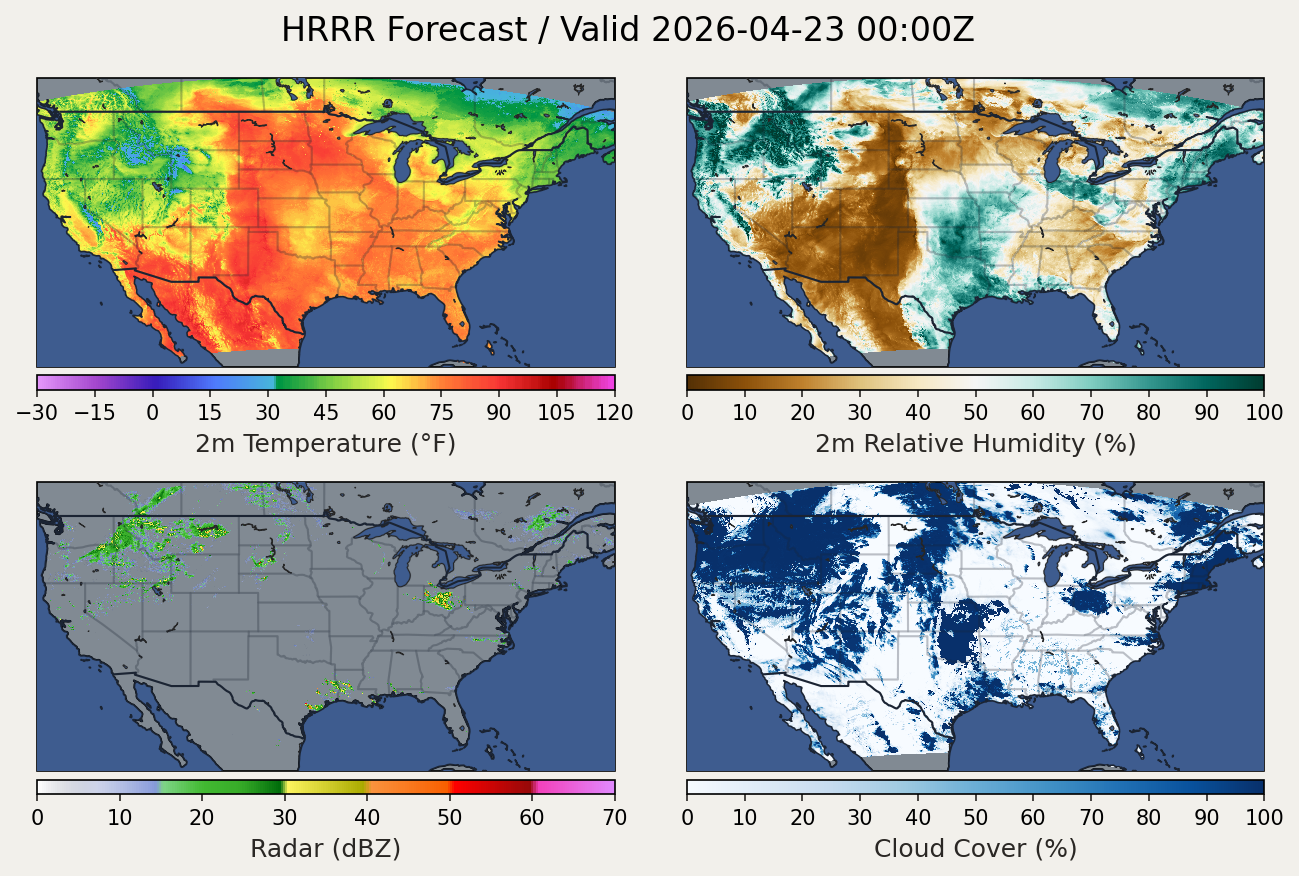

In [13]:
lat1, lon1, lat2, lon2 = (22.5,  -125,  52.5,  -66)
width_in = 6 * (lon2 - lon1) / (lat2 - lat1)
height_in = 6
dpi = 150

# Round pixel dimensions to nearest even number
width_px = round(width_in * dpi / 2) * 2
height_px = round(height_in * dpi / 2) * 2

fig = plt.figure(figsize=[width_px/dpi,height_px/dpi], dpi=dpi)
fig.set_facecolor("#f2f0eb")

axes = fig.subplots(2, 2, subplot_kw={"projection": pc}, gridspec_kw={"wspace": -0.1, "hspace":0.4})
for i in range(2):
    for j in range(2):
        fig, ax = make_plot(fig, axes[i, j])

ax = axes[0, 0]
p = ax.pcolormesh(data.longitude, data.latitude, (data.temperature_2m*(9/5))+32, cmap="tmpf", vmin=-30, vmax=120)
fig.canvas.draw()
cax = inset_axes(ax, width="100%", height="5%",
                loc="lower center",
                bbox_to_anchor=(0, -0.08, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0)

cb = plt.colorbar(
p,
cax=cax,
orientation="horizontal",
spacing="proportional",
ticks = np.arange(-30, 135, 15), 
)

cb.ax.tick_params(color="#2a2724")
cb.ax.set_xlabel("2m Temperature (°F)", color="#2a2724", size=12)

ax = axes[0, 1]
p2 = ax.pcolormesh(data.longitude, data.latitude, data.relative_humidity_2m, cmap="BrBG", vmin=0, vmax=100)
fig.canvas.draw()
cax = inset_axes(ax, width="100%", height="5%",
                loc="lower center",
                bbox_to_anchor=(0, -0.08, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0)

cb = plt.colorbar(
p2,
cax=cax,
orientation="horizontal",
spacing="proportional",
ticks = np.arange(-30, 130, 10), 
)

cb.ax.tick_params(color="#2a2724")
cb.ax.set_xlabel("2m Relative Humidity (%)", color="#2a2724", size=12)

ax = axes[1, 0]
p3 = ax.pcolormesh(data.longitude, data.latitude, data.composite_reflectivity, cmap="radar", vmin=0, vmax=70)
fig.canvas.draw()
cax = inset_axes(ax, width="100%", height="5%",
                loc="lower center",
                bbox_to_anchor=(0, -0.08, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0)

cb = plt.colorbar(
p3,
cax=cax,
orientation="horizontal",
spacing="proportional",
ticks = np.arange(0, 80, 10), 
)

cb.ax.tick_params(color="#2a2724")
cb.ax.set_xlabel("Radar (dBZ)", color="#2a2724", size=12)

ax = axes[1, 1]
p4 = ax.pcolormesh(data.longitude, data.latitude, data.total_cloud_cover_atmosphere, cmap="Blues", vmin=0, vmax=100)
fig.canvas.draw()
cax = inset_axes(ax, width="100%", height="5%",
                loc="lower center",
                bbox_to_anchor=(0, -0.08, 1, 1),
                bbox_transform=ax.transAxes,
                borderpad=0)

cb = plt.colorbar(
p4,
cax=cax,
orientation="horizontal",
spacing="proportional",
ticks = np.arange(0, 110, 10), 
)

cb.ax.tick_params(color="#2a2724")
cb.ax.set_xlabel("Cloud Cover (%)", color="#2a2724", size=12)


fig.suptitle(f"HRRR Forecast / Valid {data.valid_time.values.astype(str)[0:10] + " " + data.valid_time.values.astype(str)[11:16]}Z", y=0.95, size=16)

plt.savefig(f"cache/hrrr_surface/{data.valid_time.values.astype(str)[0:10] + "T" + data.valid_time.values.astype(str)[11:16]}", bbox_inches="tight")

In [10]:
def add_temp():
    colorlist1 = ["#E496FA", "#A346CD", "#361BBA", "#4F7AFC", "#47B7DA"]
    colorlist2 = ["#009643", "#89D244", "#FCFC4E", "#FF7835", "#F83535", "#A80000", "#EF43E1"]

    cmap = mpl.colors.LinearSegmentedColormap.from_list("temp_below", colorlist1, N=62)
    cmap2 = mpl.colors.LinearSegmentedColormap.from_list("temp_above", colorlist2, N=48)

    mpl.colormaps.register(cmap, name="temp_below", force=True)
    mpl.colormaps.register(cmap2, name="temp_above", force=True)

    cm1 = plt.get_cmap("temp_below")(np.linspace(0,1,62))
    cm2 = plt.get_cmap("temp_above")(np.linspace(0,1,88))

    colors = np.concat([cm1, cm2])
    cmap = mpl.colors.LinearSegmentedColormap.from_list('temperature', colors)
    mpl.colormaps.register(cmap, name="tmpf", force=True)
add_temp()

In [11]:
def register_radar():
    colorlist1 = ["#383D4C00", "#9AA8D57C", "#5F79CFBF"] # 0-15
    cmap1 = mpl.colors.LinearSegmentedColormap.from_list("radar1",colorlist1, N=15)
    mpl.colormaps.register(cmap1, name="r1", force=True)
    cm1 = plt.get_cmap("r1")(np.linspace(0,1,15))

    colorlist2 = ["#7FD488", "#42BA32", "#37AB28", "#006D0B"] # 15-30
    cmap2 = mpl.colors.LinearSegmentedColormap.from_list("radar2",colorlist2, N=15)
    mpl.colormaps.register(cmap2, name="r2", force=True)
    cm2 = plt.get_cmap("r2")(np.linspace(0,1,15))

    colorlist3 = ["#FCF45E", "#AAAA00"] #30-40
    cmap3 = mpl.colors.LinearSegmentedColormap.from_list("radar3",colorlist3, N=10)
    mpl.colormaps.register(cmap3, name="r3", force=True)
    cm3 = plt.get_cmap("r3")(np.linspace(0,1,10))

    colorlistO = ["#FA933E", "#F95F00",] #40-50
    cmapO = mpl.colors.LinearSegmentedColormap.from_list("radarO",colorlistO, N=10)
    mpl.colormaps.register(cmapO, name="rO", force=True)
    cmO = plt.get_cmap("rO")(np.linspace(0,1,10))

    colorlist4 = ["#FF0000", "#960909"] #50-60
    cmap4 = mpl.colors.LinearSegmentedColormap.from_list("radar4",colorlist4, N=10)
    mpl.colormaps.register(cmap4, name="r4", force=True)
    cm4 = plt.get_cmap("r4")(np.linspace(0,1,10))

    colorlist5 = ["#F340BA", "#E088FD"] #60-70
    cmap5 = mpl.colors.LinearSegmentedColormap.from_list("radar5",colorlist5, N=10)
    mpl.colormaps.register(cmap5, name="r5", force=True)
    cm5 = plt.get_cmap("r5")(np.linspace(0,1,10))

    colors = np.concat([cm1, cm2, cm3, cmO, cm4, cm5])
    cmap = mpl.colors.LinearSegmentedColormap.from_list('radar', colors)
    cmap.set_under("#00000000")
    cmap.set_over("#A31AFF")
    cmap.set_bad("#00000000")

    mpl.colormaps.register(cmap, name="radar")
register_radar()